<a id="top"></a>
Introduction

This notebook investigates a convolutional neural network (CNN) for chest X-ray image classification. The aim is to evaluate the baseline pneumonia classification model and explore ways to improve validation and test performance. The dataset contains three classes: **BACTERIAL**, **NORMAL**, and **VIRAL**. A baseline run was carried out using a trained model with the base layers frozen ("trainable = False").

# Table of Contents
1. [Training Time](#training-time)  
2. [Dataset Balance and Distribution](#dataset-balance-and-distribution)  
3. [Overfitting Analysis](#overfitting-analysis)  
4. [Global Average Pooling 2D](#global-average-pooling-2d)  
5. [Data Augmentation](#data-augmentation)  
6. [Transfer Learning](#transfer-learning)  
7. [Precision, Recall and F1 Scores](#precision-recall-and-f1-scores)  
8. [Improving Detection of Sick Patients](#improving-detection-of-sick-patients)  
9. [Visualising What the CNN Sees](#visualising-what-the-cnn-sees)  
10. [Additional Improvements from Research](#additional-improvements-from-research)  
11. [Conclusion](#conclusion)

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
import keras
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling, BatchNormalization
from keras.layers import GlobalAveragePooling2D
from keras.layers import RandomFlip, RandomRotation, RandomZoom
from keras.optimizers import RMSprop, Adam

%matplotlib inline

In [26]:
# from pneumonia_classification.py
batch_size = 12
epochs = 8
img_width = 128
img_height = 128
img_channels = 3
fit = False # as i dont want to retrain the model every time i run the notebook, set to true if you want to train the model
train_dir = 'chest_xray\\train'
test_dir = 'chest_xray\\test'

from keras.layers import Input


train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed=None,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels='inferred',
    shuffle=True)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Class Names:', class_names)

# Build model
model = tf.keras.models.Sequential([
    Input(shape=(img_height, img_width, img_channels)),
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

save_callback = tf.keras.callbacks.ModelCheckpoint("pneumonia.keras", save_freq='epoch', save_best_only=True)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class Names: ['BACTERIAL', 'NORMAL', 'VIRAL']


<h2 id="training-time">1. Training Time</h2>

This section records how long the baseline model took to train.

<a href="#top">Back to top</a>

In [30]:
if fit:
    start_time = time.time()

    history = model.fit(
        train_ds,
        batch_size=batch_size,
        validation_data=val_ds,
        callbacks=[save_callback],
        epochs=epochs
    )

    end_time = time.time()
    training_time = end_time - start_time

    print("Training time (seconds):", training_time)
    print("Training time (minutes):", training_time / 60)
else:
    model = tf.keras.models.load_model("pneumonia.keras")
    print("Model loaded from saved file. Baseline training time was recorded previously.")

Model loaded from saved file. Baseline training time was recorded previously.


<h2 id ="dataset-balance-and-distribution">Dataset Balance and Distribution</h2> 
The dataset used in this project consists of chest X-ray images grouped into three classes: **BACTERIAL**, **NORMAL**, and **VIRAL**. The dataset was stored locally and loaded from separate training and test directories.

<a href="#top">Back to top</a>

In [31]:
train_dir = 'chest_xray\\train'
test_dir = 'chest_xray\\test'
class_names = train_ds.class_names
num_classes = len(class_names)
print('Class Names:', class_names)

Class Names: ['BACTERIAL', 'NORMAL', 'VIRAL']


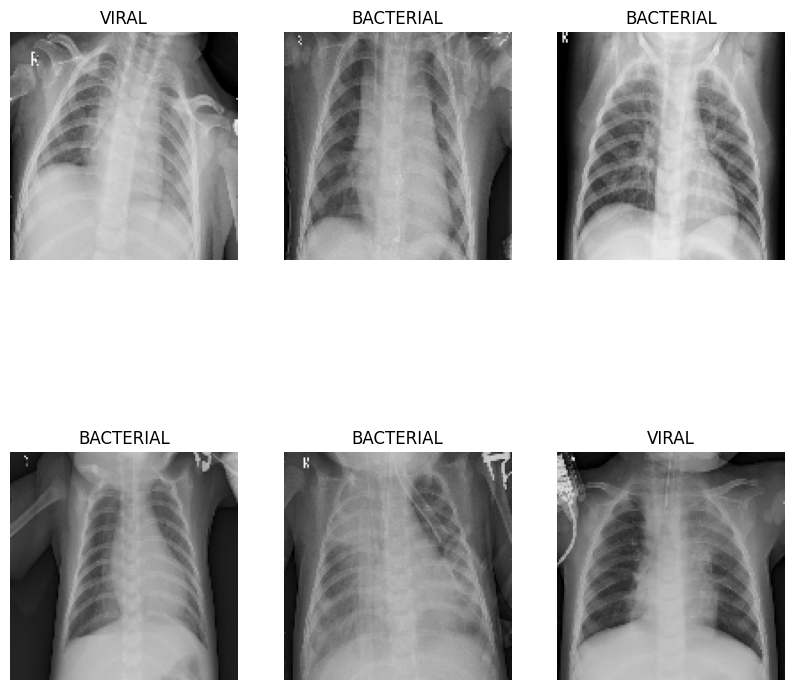

In [32]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(2):
        for i in range(6):
            ax = plt.subplot(2, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i].numpy()])
            plt.axis("off")
plt.show()

<h2 id="overfitting-analysis">3. Overfitting Analysis</h2>

This section compares training and validation performance to assess whether the model shows signs of overfitting. Overfitting can be identified when the model performs well each iteration on the training data but does not improve, or becomes worse, on validation and test data. On the first run of the training data there was a clear show of overfitting. This first run was used as a Baseline for the tests in the report.

<a href="#top">Back to top</a>

![Baseline result](images/Baseline_model_results.jpg)

<h2 id ="global-average-pooling-2d">Global Average Pooling 2D</h2> 
<a href="#top">Back to top</a>

<h2 id ="data-augmentation">Data Augmentation</h2> 
<a href="#top">Back to top</a>

<h2 id ="transfer-learning">Transfer Learning</h2> 
<a href="#top">Back to top</a>

<h2 id ="precision-recall-and-f1-scores">Precision, Recall and F1 Scores</h2> 
<a href="#top">Back to top</a>

<h2 id ="improving-detection-of-sick-patients">Improving Detection of Sick Patients</h2> 
<a href="#top">Back to top</a>

<h2 id ="visualising-what-the-cnn-sees">Visualising what the CNN Sees</h2> 
<a href="#top">Back to top</a>

<h2 id ="additional-improvements-from-research">Additional Improvements from Research</h2> 
<a href="#top">Back to top</a>

<h2 id ="conclusion">Conclusion</h2> 
<a href="#top">Back to top</a>